In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score



In [2]:
# Load the data
df = pd.read_csv('../data/processed/modeling_ready_data.csv')

In [3]:
# Quick look at position distribution
print(df['Position'].value_counts())
print()
print(df['Position'].value_counts())  

Position
D     679
C     660
LW    291
RW    239
F      31
W       6
Name: count, dtype: int64

Position
D     679
C     660
LW    291
RW    239
F      31
W       6
Name: count, dtype: int64


In [4]:
# Split into centers, wingers, and defensemen
# Hybrid labels are assigned to the first matching clean bucket; any ambiguous leftovers are excluded.

def classify_position(pos):
    pos = str(pos).strip()
    if 'D' in pos and 'C' not in pos and pos not in {'LW', 'RW', 'W', 'F', 'LW/RW'}:
        return 'D'
    if 'C' in pos:
        return 'C'
    if pos in {'LW', 'RW', 'W', 'F', 'LW/RW'}:
        return 'W'
    return 'EXCLUDE'

df['Position Group'] = df['Position'].apply(classify_position)

ctr = df[df['Position Group'] == 'C'].copy()
wing = df[df['Position Group'] == 'W'].copy()
dfd = df[df['Position Group'] == 'D'].copy()
excluded = df[df['Position Group'] == 'EXCLUDE'].copy()

print(f'Centers   : {len(ctr):,} player-seasons')
print(f'Wingers   : {len(wing):,} player-seasons')
print(f'Defenders : {len(dfd):,} player-seasons')
print(f'Excluded  : {len(excluded):,} player-seasons')
if len(excluded):
    print('Excluded labels:')
    print(excluded['Position'].value_counts())

Centers   : 660 player-seasons
Wingers   : 567 player-seasons
Defenders : 679 player-seasons
Excluded  : 0 player-seasons


In [5]:
# Re-split AFTER creating new columns
ctr = df[df['Position Group'] == 'C'].copy()
wing = df[df['Position Group'] == 'W'].copy()
dfd = df[df['Position Group'] == 'D'].copy()

# Build a broad modeling feature space from nearly all numeric columns.
# Cap-related fields are excluded for every group, and faceoff fields are excluded for non-centers.
BASE_EXCLUDE_COLS = [
    'Rk', 'Player', 'Team', 'Position', 'Position Group', 'Season', 'Player ID', 'Situation',
    'Cap Hit', 'Cap Pct'
]
FACEOFF_COLS = ['Faceoff Pct', 'FO_total_pg', 'Faceoff Impact_pg']

ALL_NUMERIC_FEATURES = [
    c for c in df.columns
    if c not in BASE_EXCLUDE_COLS
    and df[c].dtype in ['float64', 'int64']
]

CENTER_FEATURES = ALL_NUMERIC_FEATURES.copy()
WINGER_FEATURES = [c for c in ALL_NUMERIC_FEATURES if c not in FACEOFF_COLS]
DEFENSE_FEATURES = [c for c in ALL_NUMERIC_FEATURES if c not in FACEOFF_COLS]

GROUPS = {
    'Centers': {'df': ctr, 'features': CENTER_FEATURES, 'color': 'steelblue'},
    'Wingers': {'df': wing, 'features': WINGER_FEATURES, 'color': 'darkorange'},
    'Defensemen': {'df': dfd, 'features': DEFENSE_FEATURES, 'color': 'seagreen'},
}

for label, info in GROUPS.items():
    missing = [c for c in info['features'] if c not in info['df'].columns]
    if missing:
        print(f'{label} missing features: {missing}')
    print(f"{label} modeling features: {len(info['features'])}")

Centers modeling features: 79
Wingers modeling features: 76
Defensemen modeling features: 76


In [6]:
# See how many numeric columns we actually have after excluding admin and cap cols
print(f'Total numeric columns available for modeling: {len(ALL_NUMERIC_FEATURES)}')
print(ALL_NUMERIC_FEATURES)
print()
print(f'Center feature count: {len(CENTER_FEATURES)}')
print(f'Winger feature count: {len(WINGER_FEATURES)}')
print(f'Defense feature count: {len(DEFENSE_FEATURES)}')

Total numeric columns available for modeling: 79
['Age', 'Games Played', 'Fenwick For', 'Fenwick Against', 'Fenwick For Pct', 'Fenwick For Pct Relative', 'On Ice Shooting Pct', 'On Ice Save Pct', 'Player Development Index', 'Ozone Start Pct', 'TOI Per 60', 'Shot Attempts', 'Shots Through %', 'Short Handed Goals', 'Game Winning Goals', 'Even Strength points', 'PP points', 'SH points', 'Shooting Pct', 'Faceoff Pct', 'Blocks', 'Hits', 'Power Play Time On Ice', 'Short Handed Time On Ice', 'Shifts', 'Game Score', 'On Ice Fenwick Pct_MP', 'Individual Shot Attempts_MP', 'Points_MP', 'Goals_MP', 'Individual Rebounds_MP', 'Individual Rebound Goals_MP', 'Individual Freeze_MP', 'Individual Play Stopped_MP', 'Penalties Taken_MP', 'lowDangerxGoals', 'mediumDangerxGoals', 'lowDangerGoals', 'mediumDangerGoals', 'highDangerGoals', 'Individual OZone Shift Starts_MP', 'Individual DZone Shift Starts_MP', 'Individual OZone Shift Ends_MP', 'Individual DZone Shift Ends_MP', 'Penalties Drawn_MP', 'On Ice For

In [7]:
# Scale broad feature space for each position group
scalers = {}
X_group = {}

for label, info in GROUPS.items():
    scalers[label] = StandardScaler()
    X_group[label] = scalers[label].fit_transform(info['df'][info['features']])
    print(f"{label}: {X_group[label].shape}")

Centers: (660, 79)
Wingers: (567, 76)
Defensemen: (679, 76)



=== CENTERS ===
   k           BIC           AIC
--------------------------------
   2      49,078.9      19,973.7
   3      56,544.3      12,884.2
   4      66,418.6       8,203.7
   5      78,564.7       5,794.9
   6      81,430.3      -5,894.3
   7      95,755.9      -6,123.6
   8      97,091.2     -19,343.2
   9     105,510.8     -25,478.4
  10     103,227.8     -42,316.3
  11     102,451.5     -57,647.4
  12     108,522.1     -66,131.7
  13     100,943.7     -88,265.0
  14     103,675.8    -100,087.7

=== WINGERS ===
   k           BIC           AIC
--------------------------------
   2      40,140.1      14,076.2
   3      48,465.0       9,367.0
   4      55,026.3       2,894.3
   5      67,242.3       2,076.1
   6      70,993.6      -7,206.6
   7      76,507.8     -14,726.5
   8      79,900.4     -24,368.1
   9      79,309.7     -37,992.9
  10      78,451.6     -51,885.0
  11      72,383.2     -70,987.6
  12      77,929.9     -78,474.9
  13      78,036.0     -91,403.0
  14     

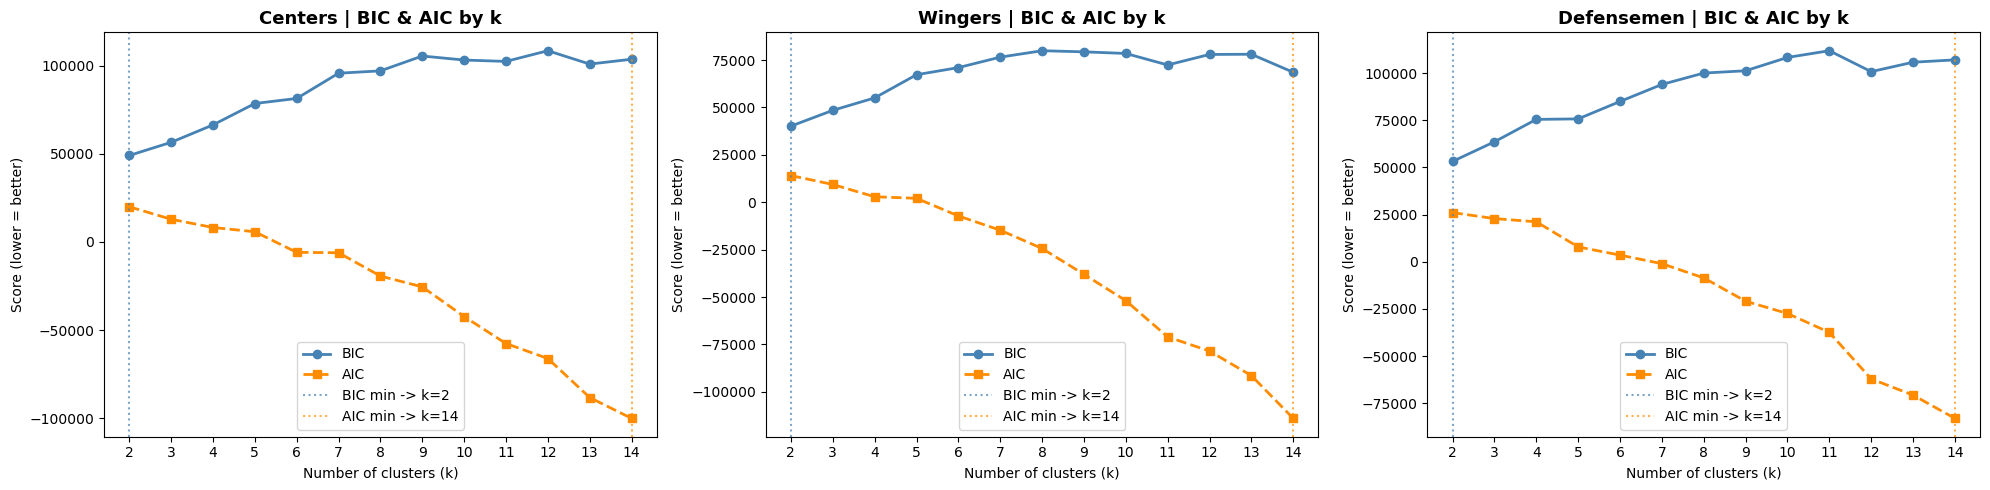

In [8]:
# BIC / AIC sweep on hand-picked feature sets
K_RANGE = range(2, 15)

def sweep_gmm(X, label):
    results = {}
    print(f'\n{label}')
    print(f'{"k":>4}  {"BIC":>12}  {"AIC":>12}')
    print('-' * 32)
    for k in K_RANGE:
        gmm = GaussianMixture(n_components=k, covariance_type='full', n_init=10, random_state=42)
        gmm.fit(X)
        results[k] = {'bic': gmm.bic(X), 'aic': gmm.aic(X), 'model': gmm}
        print(f'{k:>4}  {gmm.bic(X):>12,.1f}  {gmm.aic(X):>12,.1f}')
    return results

group_sweeps = {}
for label, info in GROUPS.items():
    group_sweeps[label] = sweep_gmm(X_group[label], f'=== {label.upper()} ===')

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, (label, sweep) in zip(axes, group_sweeps.items()):
    ks   = list(sweep.keys())
    bics = [sweep[k]['bic'] for k in ks]
    aics = [sweep[k]['aic'] for k in ks]

    ax.plot(ks, bics, 'o-', color='steelblue', linewidth=2, label='BIC')
    ax.plot(ks, aics, 's--', color='darkorange', linewidth=2, label='AIC')

    best_bic_k = ks[np.argmin(bics)]
    best_aic_k = ks[np.argmin(aics)]
    ax.axvline(best_bic_k, color='steelblue', linestyle=':', alpha=0.7, label=f'BIC min -> k={best_bic_k}')
    ax.axvline(best_aic_k, color='darkorange', linestyle=':', alpha=0.7, label=f'AIC min -> k={best_aic_k}')

    ax.set_title(f'{label} | BIC & AIC by k', fontsize=13, fontweight='bold')
    ax.set_xlabel('Number of clusters (k)')
    ax.set_ylabel('Score (lower = better)')
    ax.set_xticks(ks)
    ax.legend()

plt.tight_layout()
plt.show()

In [9]:
# Reuse the same broad feature space for PCA so both GMM stages compare the same inputs
PCA_FEATURES = {
    'Centers': CENTER_FEATURES,
    'Wingers': WINGER_FEATURES,
    'Defensemen': DEFENSE_FEATURES,
}

for label, cols in PCA_FEATURES.items():
    print(f'{label} PCA feature count: {len(cols)}')

Centers PCA feature count: 79
Wingers PCA feature count: 76
Defensemen PCA feature count: 76


Centers: 79 features -> 23 PCA components (90% variance)
Wingers: 76 features -> 22 PCA components (90% variance)
Defensemen: 76 features -> 24 PCA components (90% variance)


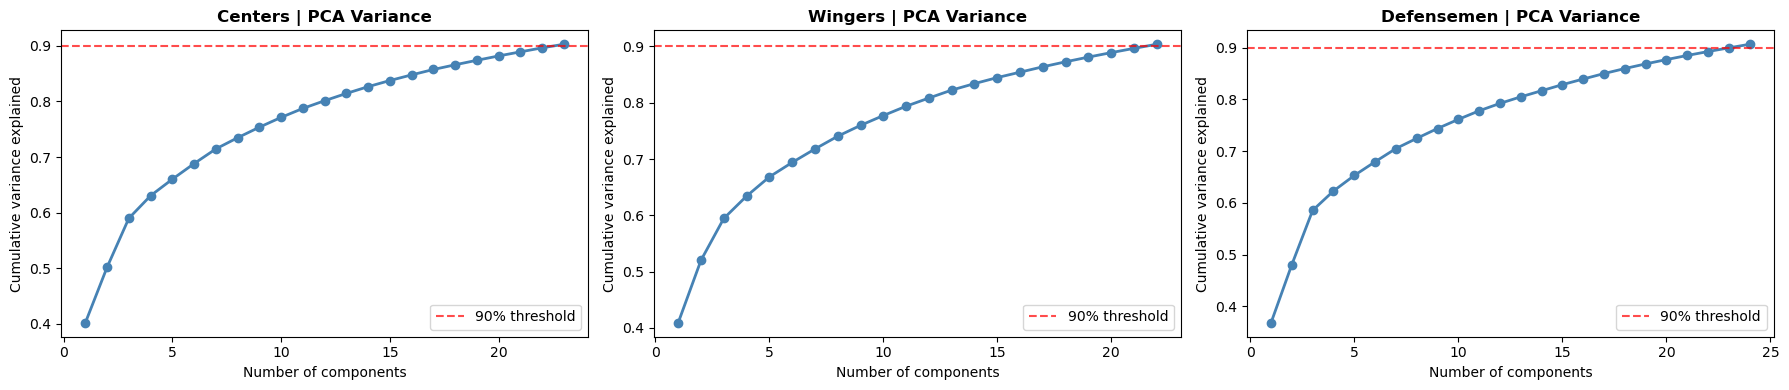

In [10]:
# PCA on the same broad feature sets used in the first GMM sweep
pca_scalers = {}
pca_models = {}
X_pca_group = {}
X_pca_raw_group = {}

for label, info in GROUPS.items():
    pca_scalers[label] = StandardScaler()
    X_pca_raw_group[label] = pca_scalers[label].fit_transform(info['df'][PCA_FEATURES[label]])

    pca_models[label] = PCA(n_components=0.90, random_state=42)
    X_pca_group[label] = pca_models[label].fit_transform(X_pca_raw_group[label])

    print(
        f"{label}: {X_pca_raw_group[label].shape[1]} features -> {X_pca_group[label].shape[1]} PCA components (90% variance)"
    )

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, (label, pca) in zip(axes, pca_models.items()):
    cumvar = np.cumsum(pca.explained_variance_ratio_)
    ax.plot(range(1, len(cumvar)+1), cumvar, 'o-', color='steelblue', linewidth=2)
    ax.axhline(0.90, color='red', linestyle='--', alpha=0.7, label='90% threshold')
    ax.set_xlabel('Number of components')
    ax.set_ylabel('Cumulative variance explained')
    ax.set_title(f'{label} | PCA Variance', fontsize=12, fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.show()

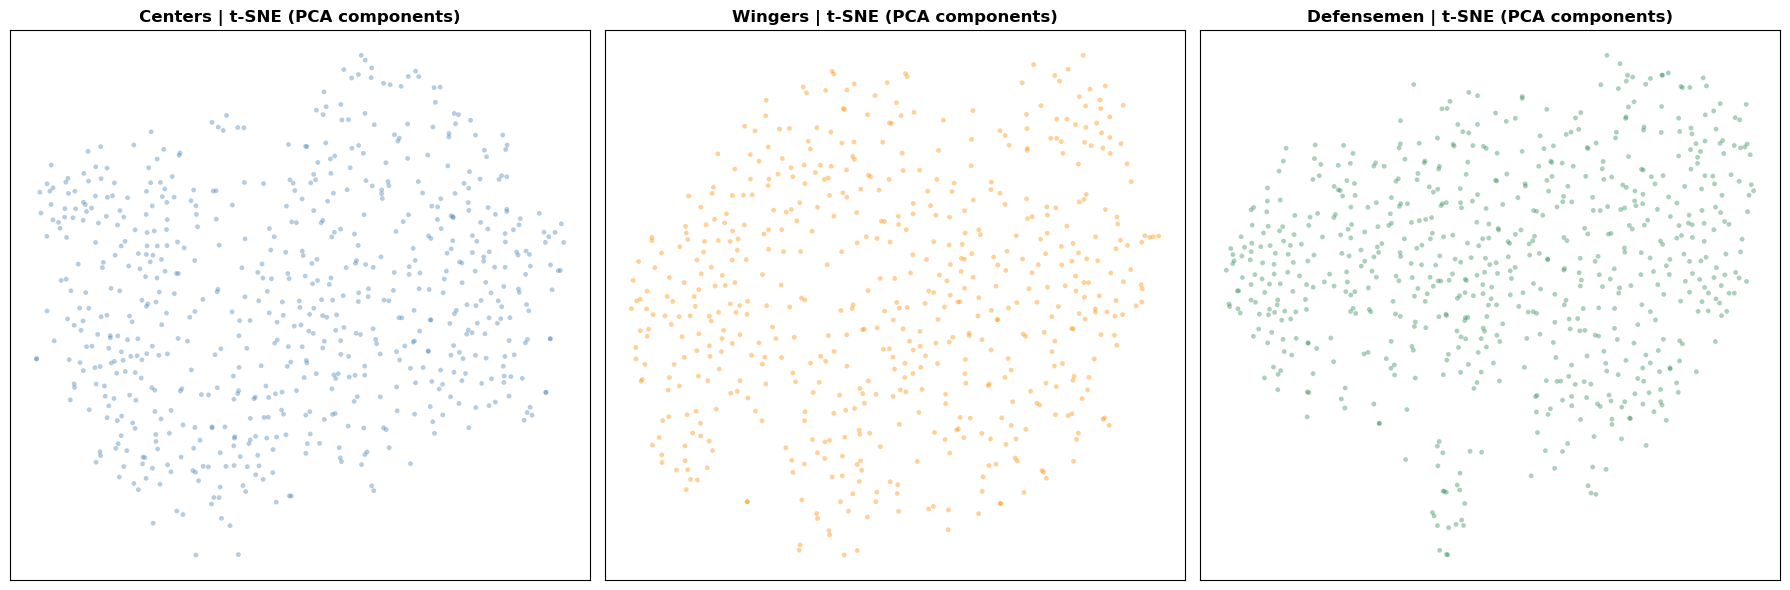

In [11]:
# t-SNE on PCA components
tsne_groups = {}
plot_groups = {}

for label, info in GROUPS.items():
    tsne = TSNE(n_components=2, perplexity=40, random_state=42, max_iter=1000)
    coords = tsne.fit_transform(X_pca_group[label])

    plot_groups[label] = info['df'].copy()
    plot_groups[label]['tsne_x'] = coords[:, 0]
    plot_groups[label]['tsne_y'] = coords[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (label, df_plot) in zip(axes, plot_groups.items()):
    ax.scatter(df_plot['tsne_x'], df_plot['tsne_y'], alpha=0.4, s=12, color=GROUPS[label]['color'], edgecolors='none')
    ax.set_title(f'{label} | t-SNE (PCA components)', fontsize=12, fontweight='bold')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

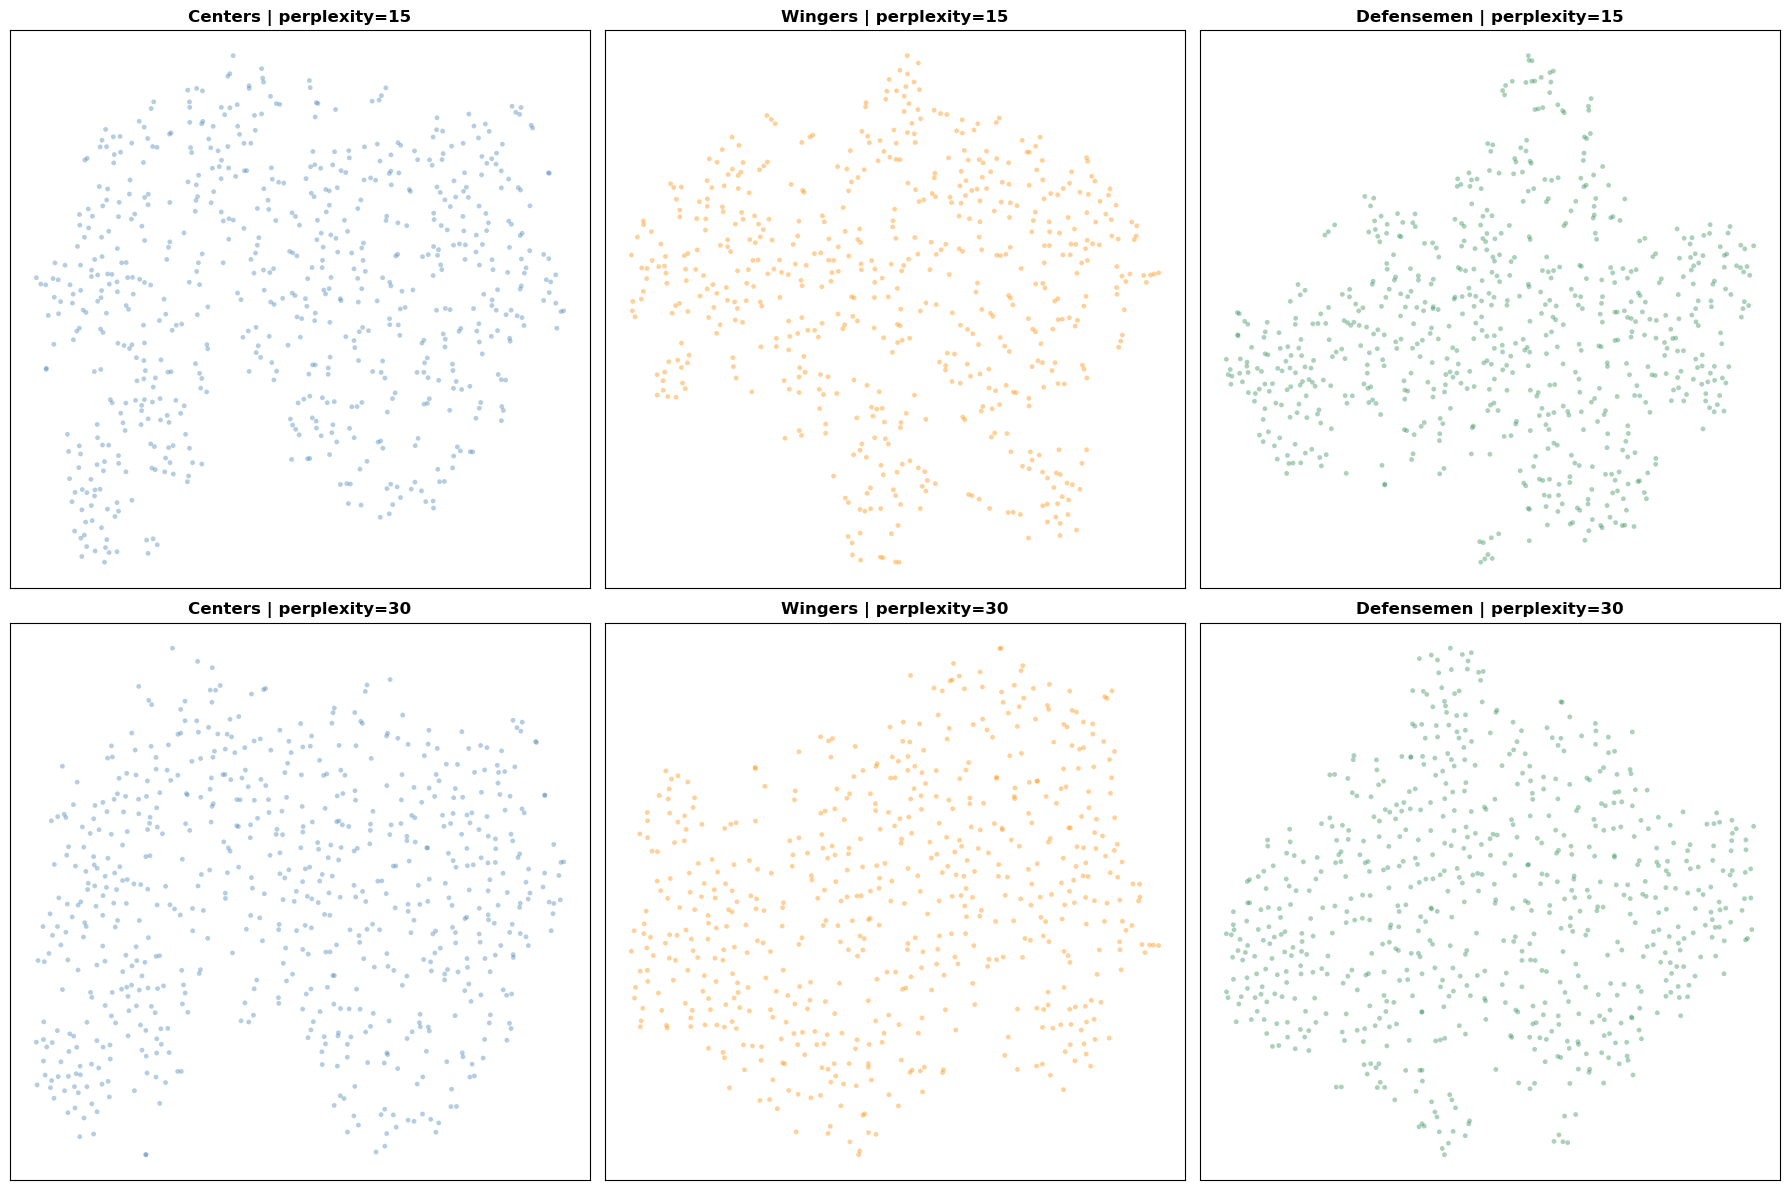

In [12]:
# t-SNE with lower perplexity to surface local structure
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for i, perp in enumerate([15, 30]):
    for j, (label, info) in enumerate(GROUPS.items()):
        tsne_test = TSNE(n_components=2, perplexity=perp, random_state=42, max_iter=1000)
        coords = tsne_test.fit_transform(X_pca_group[label])

        axes[i][j].scatter(coords[:, 0], coords[:, 1], alpha=0.4, s=12, color=info['color'], edgecolors='none')
        axes[i][j].set_title(f'{label} | perplexity={perp}', fontweight='bold')
        axes[i][j].set_xticks([])
        axes[i][j].set_yticks([])

plt.tight_layout()
plt.show()


=== CENTERS (PCA) ===
   k           BIC           AIC
--------------------------------
   2      50,903.5      48,212.6
   3      51,412.4      47,373.9
   4      52,503.7      47,117.5
   5      53,851.6      47,117.8
   6      55,172.8      47,091.3
   7      56,562.5      47,133.3
   8      57,557.6      46,780.7
   9      59,534.7      47,410.2
  10      59,672.1      46,199.9
  11      59,357.3      44,537.4
  12      61,535.6      45,368.0
  13      61,223.4      43,708.2
  14      63,592.5      44,729.6

=== WINGERS (PCA) ===
   k           BIC           AIC
--------------------------------
   2      42,111.9      39,720.4
   3      42,647.6      39,058.1
   4      43,407.7      38,620.3
   5      44,319.6      38,334.3
   6      45,622.1      38,438.8
   7      47,235.9      38,854.6
   8      48,457.9      38,878.8
   9      48,557.2      37,780.1
  10      50,172.0      38,197.0
  11      51,061.1      37,888.1
  12      50,822.5      36,451.6
  13      52,288.8      36,719

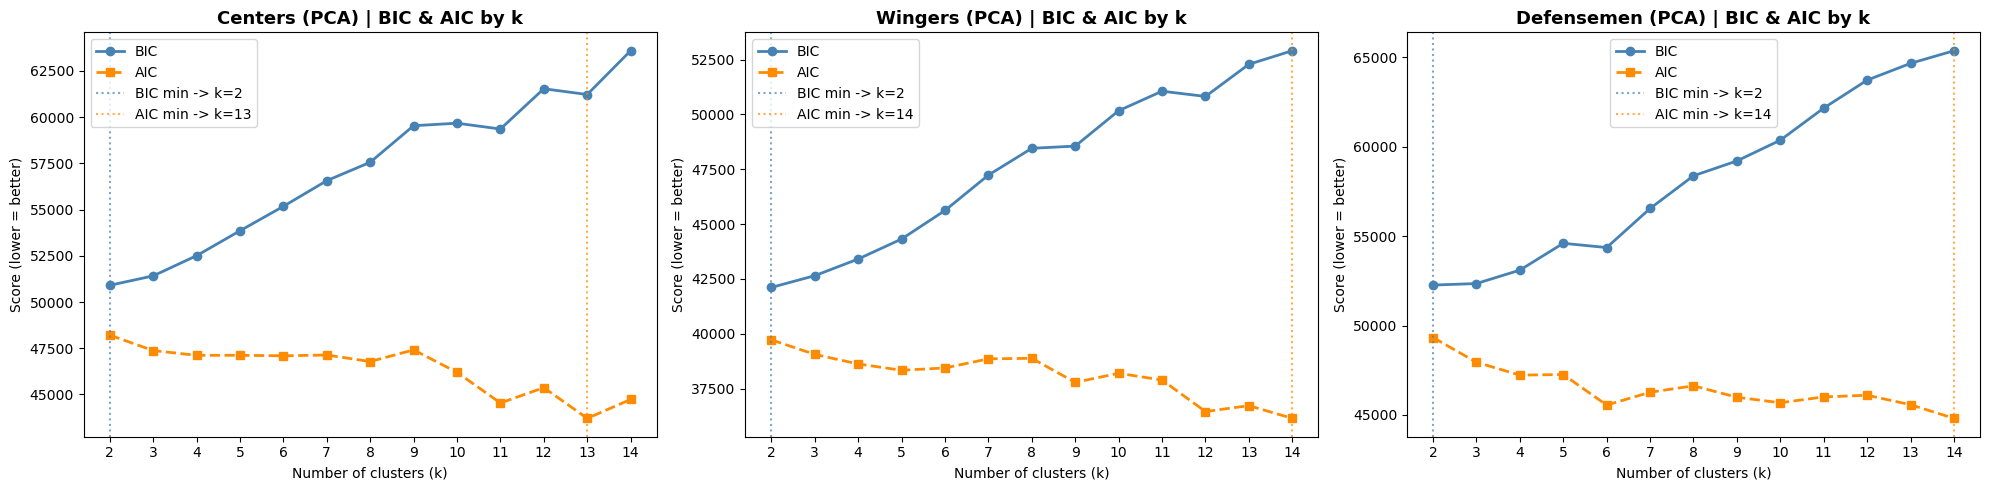

In [13]:
# BIC/AIC sweep on PCA-reduced data
group_pca_sweeps = {}
for label in GROUPS:
    group_pca_sweeps[label] = sweep_gmm(X_pca_group[label], f'=== {label.upper()} (PCA) ===')

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, (label, sweep) in zip(axes, group_pca_sweeps.items()):
    ks   = list(sweep.keys())
    bics = [sweep[k]['bic'] for k in ks]
    aics = [sweep[k]['aic'] for k in ks]

    ax.plot(ks, bics, 'o-', color='steelblue', linewidth=2, label='BIC')
    ax.plot(ks, aics, 's--', color='darkorange', linewidth=2, label='AIC')

    best_bic_k = ks[np.argmin(bics)]
    best_aic_k = ks[np.argmin(aics)]
    ax.axvline(best_bic_k, color='steelblue', linestyle=':', alpha=0.7, label=f'BIC min -> k={best_bic_k}')
    ax.axvline(best_aic_k, color='darkorange', linestyle=':', alpha=0.7, label=f'AIC min -> k={best_aic_k}')

    ax.set_title(f'{label} (PCA) | BIC & AIC by k', fontsize=13, fontweight='bold')
    ax.set_xlabel('Number of clusters (k)')
    ax.set_ylabel('Score (lower = better)')
    ax.set_xticks(ks)
    ax.legend()

plt.tight_layout()
plt.show()

In [14]:
# Compare alternative clustering models on the PCA representation
def summarize_alt_clustering(X, labels, model_name, group_label):
    unique_labels = sorted(set(labels))
    n_clusters = len([lab for lab in unique_labels if lab != -1])
    noise_points = int(np.sum(np.array(labels) == -1))
    if n_clusters >= 2:
        mask = np.array(labels) != -1
        if mask.sum() >= 2 and len(set(np.array(labels)[mask])) >= 2:
            sil = silhouette_score(X[mask], np.array(labels)[mask])
        else:
            sil = np.nan
    else:
        sil = np.nan
    print(f"{group_label} | {model_name}: clusters={n_clusters}, noise={noise_points}, silhouette={sil:.3f}" if not np.isnan(sil) else f"{group_label} | {model_name}: clusters={n_clusters}, noise={noise_points}, silhouette=NA")
    print(pd.Series(labels).value_counts().sort_index().to_string())
    print()

alt_cluster_results = {}
for label in GROUPS:
    X = X_pca_group[label]
    k = min(group_pca_sweeps[label], key=lambda kk: group_pca_sweeps[label][kk]["bic"])
    alt_cluster_results[label] = {}

    km = KMeans(n_clusters=k, n_init=25, random_state=42)
    km_labels = km.fit_predict(X)
    alt_cluster_results[label]["KMeans"] = {"model": km, "labels": km_labels}
    summarize_alt_clustering(X, km_labels, "KMeans", label)

    hc = AgglomerativeClustering(n_clusters=k, linkage="ward")
    hc_labels = hc.fit_predict(X)
    alt_cluster_results[label]["Hierarchical"] = {"model": hc, "labels": hc_labels}
    summarize_alt_clustering(X, hc_labels, "Hierarchical", label)


Centers | KMeans: clusters=2, noise=0, silhouette=0.251
0    316
1    344

Centers | Hierarchical: clusters=2, noise=0, silhouette=0.218
0    440
1    220

Wingers | KMeans: clusters=2, noise=0, silhouette=0.250
0    262
1    305

Wingers | Hierarchical: clusters=2, noise=0, silhouette=0.253
0    453
1    114

Defensemen | KMeans: clusters=2, noise=0, silhouette=0.234
0    399
1    280

Defensemen | Hierarchical: clusters=2, noise=0, silhouette=0.256
0    542
1    137



In [15]:
# Fit candidate k values and inspect cluster profiles

BASE_INSPECT_FEATURES = [
    'Age', 'TOI Per 60', 'Ozone Start Pct', 'Individual DZone Shift Starts_MP',
    'Goals_pg', 'Assists_pg', 'Points_pg', 'Even Strength Goals_pg', 'Power Play Goals_pg',
    'Individual xGoals_MP_pg', 'Primary Assists_MP_pg',
    'highDangerxGoals_pg', 'Individual Shots On Goal_MP_pg',
    'Individual Hits_MP_pg', 'Shots Blocked By Player_MP_pg',
    'Penalty Mins_pg', 'Power Play Time On Ice', 'Short Handed Time On Ice',
    'On Ice xGoals Diff_MP', 'On Ice xGoals Ratio_MP', 'Penalties Taken_MP', 'Penalties Drawn_MP'
]

INSPECT_FEATURES = {
    'Centers': BASE_INSPECT_FEATURES + ['Faceoff Pct', 'FO_total_pg', 'Faceoff Impact_pg'],
    'Wingers': BASE_INSPECT_FEATURES,
    'Defensemen': BASE_INSPECT_FEATURES,
}

def fit_and_profile(X, df_q, k, label, feature_cols):
    """Fit GMM, print cluster profiles and sample players."""
    gmm = GaussianMixture(n_components=k, covariance_type='full', n_init=10, random_state=42)
    gmm.fit(X)

    df_out = df_q.copy()
    df_out['cluster'] = gmm.predict(X)
    df_out['cluster_prob'] = gmm.predict_proba(X).max(axis=1)

    print(f'\n{"="*60}')
    print(f'{label}  |  k={k}')
    print(f'{"="*60}')
    print(f'Cluster sizes:\n{df_out["cluster"].value_counts().sort_index().to_string()}')

    valid_feats = [f for f in feature_cols if f in df_out.columns]
    profile = df_out.groupby('cluster')[valid_feats].mean().round(3)
    if 'Points_pg' in profile.columns:
        profile = profile.sort_values('Points_pg', ascending=False)
    print('\nCluster profiles (sorted by PTS/game):')
    print(profile.to_string())

    print('\nSample players per cluster (highest assignment confidence):')
    sample_cols = ['Player', 'Season', 'Team', 'Position', 'Age', 'Games Played', 'Goals_pg', 'Assists_pg', 'Points_pg', 'TOI Per 60', 'cluster', 'cluster_prob']
    sample_cols = [c for c in sample_cols if c in df_out.columns]
    for cid in sorted(df_out['cluster'].unique()):
        grp = df_out[df_out['cluster'] == cid].nlargest(5, 'cluster_prob')[sample_cols]
        print(f'\n  Cluster {cid}:')
        print(grp.to_string(index=False))

    return df_out, gmm

K_CANDIDATES = {
    'Centers': [3, 5, 7],
    'Wingers': [3, 5, 7],
    'Defensemen': [3, 4, 6],
}

group_results = {}
for label, ks in K_CANDIDATES.items():
    group_results[label] = {}
    for k in ks:
        df_out, gmm = fit_and_profile(X_pca_group[label], plot_groups[label], k, label.upper(), INSPECT_FEATURES[label])
        group_results[label][k] = {'df': df_out, 'gmm': gmm}


CENTERS  |  k=3
Cluster sizes:
cluster
0    242
1    249
2    169

Cluster profiles (sorted by PTS/game):
            Age  TOI Per 60  Ozone Start Pct  Individual DZone Shift Starts_MP  Goals_pg  Assists_pg  Points_pg  Even Strength Goals_pg  Power Play Goals_pg  Individual xGoals_MP_pg  Primary Assists_MP_pg  highDangerxGoals_pg  Individual Shots On Goal_MP_pg  Individual Hits_MP_pg  Shots Blocked By Player_MP_pg  Penalty Mins_pg  Power Play Time On Ice  Short Handed Time On Ice  On Ice xGoals Diff_MP  On Ice xGoals Ratio_MP  Penalties Taken_MP  Penalties Drawn_MP  Faceoff Pct  FO_total_pg  Faceoff Impact_pg
cluster                                                                                                                                                                                                                                                                                                                                                                                       

In [16]:
# Re-run scaling on the broad feature space
scalers = {}
X_group = {}
for label, info in GROUPS.items():
    scalers[label] = StandardScaler()
    X_group[label] = scalers[label].fit_transform(plot_groups[label][info['features']])

# Re-run PCA scaling on the same broad feature space
pca_scalers = {}
pca_models = {}
X_pca_raw_group = {}
X_pca_group = {}
for label, info in GROUPS.items():
    pca_scalers[label] = StandardScaler()
    X_pca_raw_group[label] = pca_scalers[label].fit_transform(plot_groups[label][PCA_FEATURES[label]])
    pca_models[label] = PCA(n_components=0.90, random_state=42)
    X_pca_group[label] = pca_models[label].fit_transform(X_pca_raw_group[label])

for label in GROUPS:
    print(f'{label} feature shape: {X_group[label].shape}')
    print(f'{label} PCA shape: {X_pca_group[label].shape}')

Centers feature shape: (660, 79)
Centers PCA shape: (660, 23)
Wingers feature shape: (567, 76)
Wingers PCA shape: (567, 22)
Defensemen feature shape: (679, 76)
Defensemen PCA shape: (679, 24)


In [17]:
# Re-run just the candidates we're locking in
FINAL_K = {
    'Centers': 5,
    'Wingers': 5,
    'Defensemen': 4,
}

final_results = {}
for label, k in FINAL_K.items():
    df_out, gmm = fit_and_profile(X_pca_group[label], plot_groups[label], k, label.upper(), INSPECT_FEATURES[label])
    final_results[label] = {'df': df_out, 'gmm': gmm}


CENTERS  |  k=5
Cluster sizes:
cluster
0    165
1     89
2    117
3     87
4    202

Cluster profiles (sorted by PTS/game):
            Age  TOI Per 60  Ozone Start Pct  Individual DZone Shift Starts_MP  Goals_pg  Assists_pg  Points_pg  Even Strength Goals_pg  Power Play Goals_pg  Individual xGoals_MP_pg  Primary Assists_MP_pg  highDangerxGoals_pg  Individual Shots On Goal_MP_pg  Individual Hits_MP_pg  Shots Blocked By Player_MP_pg  Penalty Mins_pg  Power Play Time On Ice  Short Handed Time On Ice  On Ice xGoals Diff_MP  On Ice xGoals Ratio_MP  Penalties Taken_MP  Penalties Drawn_MP  Faceoff Pct  FO_total_pg  Faceoff Impact_pg
cluster                                                                                                                                                                                                                                                                                                                                                                     